In [1]:
import yfinance as yf
import pandas as pd
import ta
import requests
import json
from datetime import datetime, timezone, timedelta
import time
import pickle
import os
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL = "gemma4"

# Cache settings
CACHE_DIR = Path("data_cache")
CACHE_DURATION_MINUTES = 60  # Cache data for 60 minutes

# Create cache directory if it doesn't exist
CACHE_DIR.mkdir(exist_ok=True)

In [3]:
def get_cached_data(symbol, interval, period):
    """Get cached data or download if expired/missing"""
    cache_key = f"{symbol}_{interval}_{period}".replace("=", "_").replace("/", "_")
    cache_file = CACHE_DIR / f"{cache_key}.pkl"
    
    # Check if cache exists and is still valid
    if cache_file.exists():
        cache_age = datetime.now() - datetime.fromtimestamp(cache_file.stat().st_mtime)
        if cache_age < timedelta(minutes=CACHE_DURATION_MINUTES):
            print(f"✓ Using cached data (age: {cache_age.seconds//60}m {cache_age.seconds%60}s)")
            with open(cache_file, 'rb') as f:
                return pickle.load(f)
        else:
            print(f"✗ Cache expired (age: {cache_age.seconds//60}m)")
    
    # Download fresh data
    print(f"⬇ Downloading fresh data for {symbol}...")
    df = yf.download(symbol, interval=interval, period=period, auto_adjust=False)
    
    # Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    # Save to cache
    with open(cache_file, 'wb') as f:
        pickle.dump(df, f)
    
    return df

def get_session():
    hour = datetime.now(timezone.utc).hour
    
    if 7 <= hour < 16:
        return "London"
    elif 13 <= hour < 22:
        return "New York"
    else:
        return "Asian"

In [4]:
def fetch_data():
    # Use cached data
    df = get_cached_data("EURUSD=X", interval="5m", period="1d")
    
    # RSI
    df["rsi"] = ta.momentum.RSIIndicator(close=df["Close"], window=14).rsi()
    
    # MACD
    macd = ta.trend.MACD(close=df["Close"])
    df["macd"] = macd.macd()
    df["macd_signal"] = macd.macd_signal()
    
    return df.dropna()

In [5]:
def build_signal(df):
    last = df.iloc[-1]
    
    return {
        "pair": "EUR/USD",
        "price": float(last["Close"]),
        "rsi": float(last["rsi"]),
        "macd": "bullish" if last["macd"] > last["macd_signal"] else "bearish",
        "trend": "uptrend" if last["Close"] > df["Close"].rolling(20).mean().iloc[-1] else "downtrend",
        "session": get_session(),
        "volatility": "high" if df["Close"].pct_change().std() > 0.0005 else "low"
    }

In [6]:
def analyze_signal(data):
    prompt = f"""Based on this forex data, respond ONLY with valid JSON (no explanation):

{json.dumps(data, indent=2)}

Output format:
{{"signal": "BUY or SELL or HOLD", "confidence": 0-100, "reason": "brief reason"}}"""
    
    try:
        response = requests.post(
            OLLAMA_URL,
            json={
                "model": MODEL,
                "prompt": prompt,
                "stream": False,
                "format": "json",  # Force JSON output
                "options": {
                    "temperature": 0.1,
                    "num_predict": 500
                }
            },
            timeout=30
        )
        
        # Check HTTP status
        response.raise_for_status()
        
        # Parse response
        response_data = response.json()
        
        # Check both 'response' and 'thinking' fields
        raw_response = response_data.get("response", "").strip()
        if not raw_response:
            raw_response = response_data.get("thinking", "").strip()
        
        # Debug: Uncomment the line below to see raw LLM response
        # print("Raw LLM response:", raw_response)
        
        if not raw_response:
            raise ValueError(f"Empty response from LLM. Full response: {response_data}")
        
        # Try to extract JSON from the response
        try:
            # First, try parsing directly
            return json.loads(raw_response)
        except json.JSONDecodeError:
            # Try to find JSON object in the response
            import re
            json_match = re.search(r'\{[^{}]+\}', raw_response, re.DOTALL)
            if json_match:
                return json.loads(json_match.group())
            else:
                raise ValueError(f"No valid JSON found in response: {raw_response}")
    
    except requests.exceptions.ConnectionError:
        raise ConnectionError(f"Cannot connect to Ollama at {OLLAMA_URL}. Is Ollama running?")
    except requests.exceptions.Timeout:
        raise TimeoutError("Request to Ollama timed out")
    except requests.exceptions.HTTPError as e:
        raise RuntimeError(f"HTTP error from Ollama: {e}")

In [7]:
df = fetch_data()
signal = build_signal(df)

# Display analysis
print("=" * 60)
print("📊 FOREX TRADING ANALYSIS - EUR/USD")
print("=" * 60)
print()

# Market Data Section
print("📈 MARKET DATA:")
print(f"   Price:        {signal['price']:.5f}")
print(f"   Session:      {signal['session']}")
print(f"   Volatility:   {signal['volatility'].upper()}")
print()

# Technical Indicators
print("📉 TECHNICAL INDICATORS:")
print(f"   RSI:          {signal['rsi']:.2f}", end="")
if signal['rsi'] < 30:
    print(" (OVERSOLD 🔴)")
elif signal['rsi'] > 70:
    print(" (OVERBOUGHT 🟢)")
else:
    print(" (NEUTRAL ⚪)")

print(f"   MACD:         {signal['macd'].upper()}", end="")
print(" 🔴" if signal['macd'] == 'bearish' else " 🟢")

print(f"   Trend:        {signal['trend'].upper()}", end="")
print(" 📉" if signal['trend'] == 'downtrend' else " 📈")
print()

# AI Analysis
print("🤖 AI ANALYSIS:")
result = analyze_signal(signal)

# Extract and format AI response
signal_emoji = {
    "BUY": "🟢",
    "SELL": "🔴",
    "HOLD": "🟡"
}

ai_signal = result.get('signal', 'UNKNOWN').upper()
confidence = result.get('confidence', 0)
reason = result.get('reason', 'No reason provided')

print(f"   Signal:       {ai_signal} {signal_emoji.get(ai_signal, '⚪')}")
print(f"   Confidence:   {confidence}%", end="")
if confidence >= 70:
    print(" (HIGH)")
elif confidence >= 40:
    print(" (MEDIUM)")
else:
    print(" (LOW)")
print(f"   Reason:       {reason}")
print()

# Summary
print("=" * 60)
if ai_signal == "BUY":
    print("💡 RECOMMENDATION: Consider BUYING EUR/USD")
elif ai_signal == "SELL":
    print("💡 RECOMMENDATION: Consider SELLING EUR/USD")
else:
    print("💡 RECOMMENDATION: HOLD position - Wait for better setup")
print("=" * 60)

✓ Using cached data (age: 13m 9s)
📊 FOREX TRADING ANALYSIS - EUR/USD

📈 MARKET DATA:
   Price:        1.14116
   Session:      London
   Volatility:   LOW

📉 TECHNICAL INDICATORS:
   RSI:          38.27 (NEUTRAL ⚪)
   MACD:         BEARISH 🔴
   Trend:        DOWNTREND 📉

🤖 AI ANALYSIS:
   Signal:       SELL 🔴
   Confidence:   85% (HIGH)
   Reason:       The combination of a downtrend, bearish MACD, and low volatility suggests continued downward pressure on EUR/USD.

💡 RECOMMENDATION: Consider SELLING EUR/USD


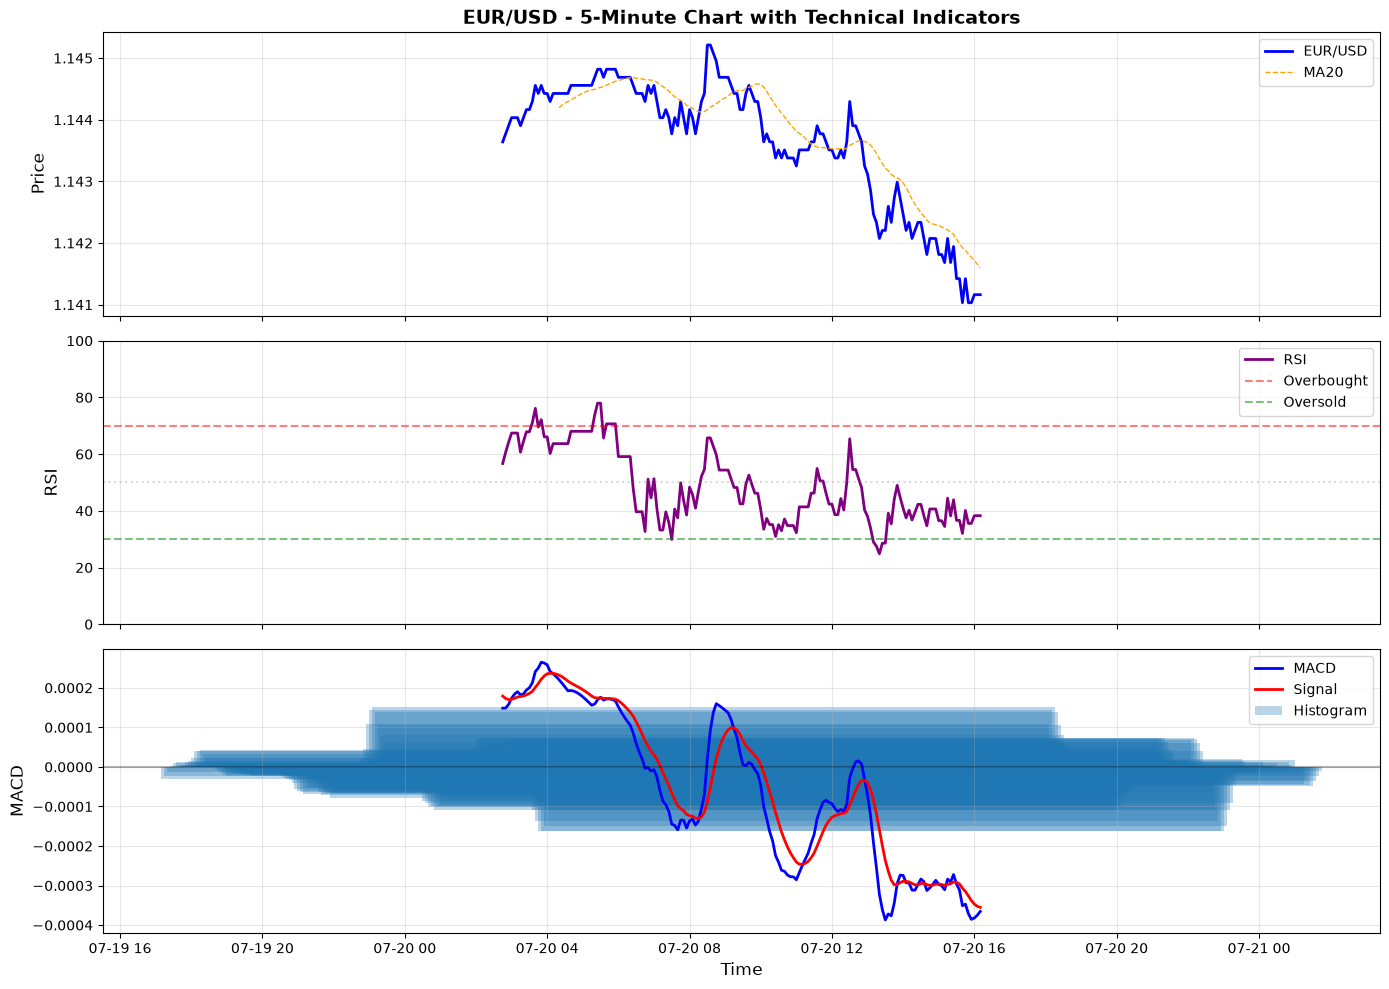

In [8]:
# Visualize the data with charts
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Price and Moving Average
ax1.plot(df.index, df['Close'], label='EUR/USD', linewidth=2, color='blue')
ma20 = df['Close'].rolling(20).mean()
ax1.plot(df.index, ma20, label='MA20', linewidth=1, color='orange', linestyle='--')
ax1.set_ylabel('Price', fontsize=12)
ax1.set_title('EUR/USD - 5-Minute Chart with Technical Indicators', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# RSI
ax2.plot(df.index, df['rsi'], label='RSI', linewidth=2, color='purple')
ax2.axhline(y=70, color='r', linestyle='--', alpha=0.5, label='Overbought')
ax2.axhline(y=30, color='g', linestyle='--', alpha=0.5, label='Oversold')
ax2.axhline(y=50, color='gray', linestyle=':', alpha=0.3)
ax2.set_ylabel('RSI', fontsize=12)
ax2.set_ylim(0, 100)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# MACD
ax3.plot(df.index, df['macd'], label='MACD', linewidth=2, color='blue')
ax3.plot(df.index, df['macd_signal'], label='Signal', linewidth=2, color='red')
ax3.bar(df.index, df['macd'] - df['macd_signal'], label='Histogram', alpha=0.3)
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax3.set_ylabel('MACD', fontsize=12)
ax3.set_xlabel('Time', fontsize=12)
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()